In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
import lalsimulation as lalsim
import numpy as np
import matplotlib.pyplot as plt

import esigmapy
from esigmapy.python_codes import generator_python as gp
from esigmapy.python_codes import esigma_pn_main as espn

No version information file '.version' found


In [2]:
import os

os.environ["RadiationPNOrder"] = '8'
os.environ["ModePNOrder"] = '4'

x=os.environ.get("RadiationPNOrder")
y=os.environ.get("ModePNOrder")

print('radiation PN order is ' + ('not set' if x is None else str(int(x))))
print('mode PN order is ' + ('not set' if y is None else str(int(y))))

y=os.environ.get("LAL_DATA_PATH")
print('Poof!' if y is None else y)

radiation PN order is 8
mode PN order is 4
:/home/samanwaya/nrsur7dq4


## Set the parameters

In [9]:
m1 = 8.0  # masses (in solar masses)
m2 = 48.0
spin1z = 0.8  # dimensionless spins
spin2z = -0.8
eccentricity = 0.3  # starting eccentricity
mean_anomaly = 60 * np.pi / 180.0  # starting mean anomaly

# Creating modes list
modes_to_use = []
for l in [2,3]:
    for m in range(-l,l+1):
        if m==0: continue
        modes_to_use.append((l,m))
modes_to_use.extend([(4,4),(4,-4),])  

print('Modes to include:',modes_to_use)
#-------------------

distance = 400.0  # source luminosity distance (in Mpc)
inclination = 30 * np.pi / 180.0  # orbital inclination with line-of-sight

f_low = 20.0  # starting frequency (in Hz)
delta_t = 1 / 2**10  # time grid-spacing (in s)

# storing factors to take to geometric units if needed
strain_fac = (distance*1e6*lal.PC_SI/lal.C_SI)/((m1+m2)*lal.MTSUN_SI)
time_fac = 1/((m1+m2)*lal.MTSUN_SI)

Modes to include: [(2, -2), (2, -1), (2, 1), (2, 2), (3, -3), (3, -2), (3, -1), (3, 1), (3, 2), (3, 3), (4, 4), (4, -4)]


## ============== Extracting modes ====================

### Inspiral ESIGMA modes

In [10]:
print('================ Python ================')
inspiral_modes_py = gp.get_inspiral_esigma_modes_py(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    # inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    verbose=True
)

print('================= C =================')
inspiral_modes_c = esigmapy.get_inspiral_esigma_modes(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    # inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    verbose=True
)

# for mode in modes_to_use: 
#     inspiral_modes_c[mode] = inspiral_modes_c[mode][2:] # trimming the first two entries to make the arrays same in length
#     inspiral_modes_py[mode] = inspiral_modes_py[mode][2:] # trimming the first entry to discard initial time flucatuations

================ Python ================
Orbital evolution took: 1.5863845809999475 seconds
Modes generation took: 0.9311780489999819 seconds
================= C =================
Orbital evolution took: 0.0230427660001169 seconds
Modes generation took: 0.0905804829999397 seconds


907
908


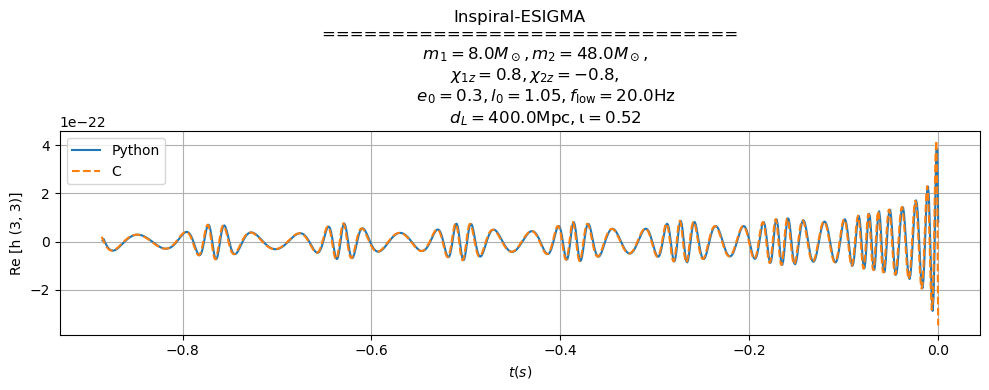

ValueError: different epoch, -0.884765625 vs -0.8857421875

In [11]:
plot_mode = (3,3)

hlm_py_real_inspiral = inspiral_modes_py[plot_mode].copy().real()
hlm_c_real_inspiral = inspiral_modes_c[plot_mode].copy().real() 

print(len(hlm_py_real_inspiral))
print(len(hlm_c_real_inspiral))

plt.figure(figsize=(10, 4))
plt.title(
    rf"""Inspiral-ESIGMA
    ==============================
      $m_1={m1} M_\odot, m_2={m2} M_\odot$, 
      $\chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$, 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)

plt.plot(hlm_py_real_inspiral.sample_times,hlm_py_real_inspiral,label='Python')
plt.plot(hlm_c_real_inspiral.sample_times,hlm_c_real_inspiral,label='C',ls='--')

plt.xlabel(r"$t (s)$")
plt.ylabel(f"Re [h {plot_mode}]")
plt.legend()
plt.grid()
# plt.xlim(0.7,0.74)
# plt.ylim(-1e-21,1e-21)
plt.tight_layout()
plt.show()

### Plotting difference ##

eps = 1e-30
abs_diff = np.abs(inspiral_modes_py[plot_mode]-inspiral_modes_c[plot_mode])
rel_diff = abs_diff / np.maximum(np.abs(inspiral_modes_c[plot_mode]), eps)

plt.figure(figsize=(10, 4))
plt.plot(hlm_py_real_inspiral.sample_times,rel_diff)
plt.xlabel(r"$t (s)$")
plt.ylabel('absolute difference')
plt.grid()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))
plt.semilogy(hlm_py_real_inspiral.sample_times,abs_diff)
plt.xlabel(r"$t (s)$")
plt.ylabel('absolute difference')
plt.grid()
plt.tight_layout()
plt.show()

### Match between individual modes

In [ ]:
from pycbc.filter import match
from pycbc.psd import aLIGOZeroDetHighPower

f_low = 20.5
print(f'{"Mode":<10} | {"Mismatch (%)":>12}')
print('-' * 25)

for mode in modes_to_use:
    hlm_py = inspiral_modes_py[mode].real()
    hlm_c = inspiral_modes_c[mode].real()
    
    tlen = max(len(hlm_c), len(hlm_py))
    hlm_c.resize(tlen)
    hlm_py.resize(tlen)
    
    delta_f = 1.0 / hlm_c.duration
    flen = tlen//2 + 1
    psd = aLIGOZeroDetHighPower(flen, delta_f, f_low)
    
    match1, _ = match(hlm_c, hlm_py, psd=psd, low_frequency_cutoff=f_low)
    mm = (1 - match1) * 100
    flag = "  <--" if mm > 0.1 else ""
    print(f'{str(mode):<10} | {mm:>12.4f}{flag}')

Mode       | Mismatch (%)
-------------------------
(2, -2)    |       0.0235
(2, -1)    |       0.0059
(2, 1)     |       0.0059
(2, 2)     |       0.0235
(3, -3)    |       0.0305
(3, -2)    |       0.0221
(3, -1)    |       0.0512
(3, 1)     |       0.0512
(3, 2)     |       0.0221
(3, 3)     |       0.0305
(4, 4)     |       0.0324
(4, -4)    |       0.0324


### IMR ESIGMA modes

In [6]:
from esigmapy.python_codes import generator_python as gp

# m1 = 20.0  # masses (in solar masses)
# m2 = 30.0
# spin1z = 0.5  # dimensionless spins
# spin2z = -0.3
# eccentricity = 0.15  # starting eccentricity
# mean_anomaly = 60 * np.pi / 180.0  # starting mean anomaly
# modes_to_use = [(2, 2), (2, -2)]  # Only using the (2,2) mode

# distance = 400.0  # source luminosity distance (in Mpc)
# inclination = 30 * np.pi / 180.0  # orbital inclination with line-of-sight

# f_low = 20.0  # starting frequency (in Hz)
# delta_t = 1 / 2**12  # time grid-spacing (in s)

print('================ Python ================')
imr_modes_py = gp.get_imr_esigma_modes_py(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    # inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    mode_to_align_by=plot_mode,
    verbose=True
)

print('================= C =================')
imr_modes_c = esigmapy.get_imr_esigma_modes(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    # inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    mode_to_align_by=plot_mode,
    verbose=True
)


================ Python ================
Orbital evolution took: 0.8255226190012763 seconds
Modes generation took: 0.9974629320022359 seconds
0.4. The orbital eccentricity at the end of inspiral was
0.04529686788536343. The merger-ringdown attachment with a quasicircular
model might be affected.
Generating MR waveform from 26.534760077516623Hz...
Hybridizing the following modes: [(2, -2), (2, -1), (2, 1), (2, 2), (3, -3), (3, -2), (3, -1), (3, 1), (3, 2), (3, 3), (4, 4), (4, -4)]
By aligning (3, 3) mode
..and inheriting the phase/time shifts for alignment of [(2, -2), (2, -1), (2, 1), (2, 2), (3, -3), (3, -2), (3, -1), (3, 1), (3, 2), (4, 4), (4, -4), (3, 3)] modes
INSPIRAL mode (2, -2) goes from -101.3546327642494Hz to 232.91499581554135Hz
MERGER mode (2, -2) goes from -1445.6670577656257Hz to 1960.0435620552219Hz
INSPIRAL mode (2, -1) goes from -40.93098520474169Hz to 48.64173777218727Hz
MERGER mode (2, -1) goes from -1494.4500188070979Hz to 638.6670205711117Hz
INSPIRAL mode (2, 1) g

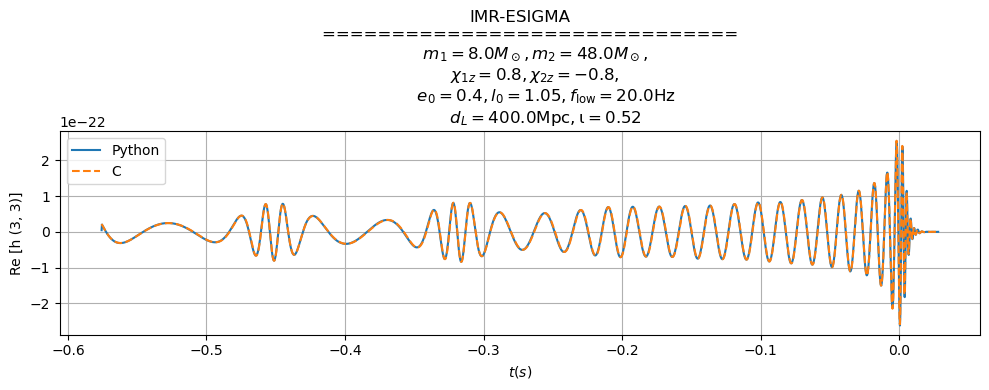

In [7]:
hp_py_real_imr = imr_modes_py[plot_mode].real()
hp_c_real_imr = imr_modes_c[plot_mode].real()
plt.figure(figsize=(10, 4))
plt.title(
    rf"""IMR-ESIGMA
    ==============================
      $m_1={m1} M_\odot, m_2={m2} M_\odot$, 
      $\chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$, 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)
# hp.plot(label=r"$h_+$")
# hc.plot(label=r"$h_\times$")

plt.plot(hp_py_real_imr.sample_times,hp_py_real_imr,label='Python')
plt.plot(hp_c_real_imr.sample_times,hp_c_real_imr,label='C',ls='--')

plt.xlabel(r"$t (s)$")
plt.ylabel(f"Re [h {plot_mode}]")
plt.legend()
plt.grid()
plt.tight_layout()

dict_keys([(4, 4), (4, -4)])


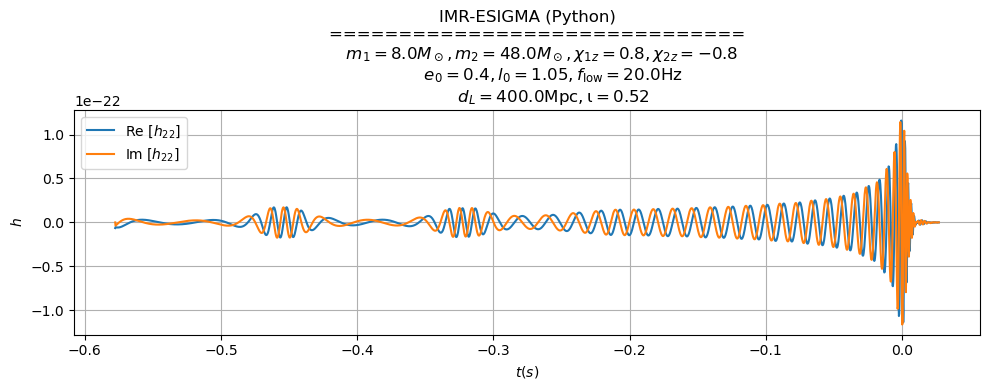

In [14]:
print(imr_modes_py.keys())
hp22_imr = imr_modes_py[plot_mode].real()
hc22_imr = imr_modes_py[plot_mode].imag()
plt.figure(figsize=(10, 4))
plt.title(
    rf"""IMR-ESIGMA (Python)
    ==============================
      $m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$ 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)
# hp.plot(label=r"$h_+$")
# hc.plot(label=r"$h_\times$")

plt.plot(hp22_imr.sample_times,hp22_imr,label=r"Re [$h_{22}$]")
plt.plot(hc22_imr.sample_times,hc22_imr,label=r"Im [$h_{22}$]")

plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.legend()
plt.grid()
plt.tight_layout()

## ============== Extracting waveform =================

In [80]:
print('================ Python ================')
hp_py, hc_py = gp.get_imr_esigma_waveform_py(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    # inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    verbose=1
)

print('================= C =================')
hp_c, hc_c = esigmapy.get_imr_esigma_waveform(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    # inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    verbose=1
)

## adjust arrays
hp_py, hc_py = hp_py[3:-2], hc_py[3:-2]
hp_c, hc_c = hp_c[2:-2], hc_c[2:-2]

================ Python ================
Orbital evolution took: 0.8285874569992302 seconds
Modes generation took: 0.9951321380031004 seconds
0.4. The orbital eccentricity at the end of inspiral was
0.04529686788536343. The merger-ringdown attachment with a quasicircular
model might be affected.
Generating MR waveform from 26.534760077516626Hz...
Hybridizing the following modes: [(2, -2), (2, -1), (2, 1), (2, 2), (3, -3), (3, -2), (3, -1), (3, 1), (3, 2), (3, 3), (4, 4), (4, -4)]
By aligning (2, 2) mode
..and inheriting the phase/time shifts for alignment of [(2, -2), (2, -1), (2, 1), (3, -3), (3, -2), (3, -1), (3, 1), (3, 2), (3, 3), (4, 4), (4, -4), (2, 2)] modes
INSPIRAL mode (2, -2) goes from -101.3546327642494Hz to 232.91499581554135Hz
MERGER mode (2, -2) goes from -1445.6670577642733Hz to 1960.0435620551568Hz
INSPIRAL mode (2, -1) goes from -40.93098520474169Hz to 48.64173777218727Hz
MERGER mode (2, -1) goes from -1494.450018807084Hz to 638.6670205710793Hz
INSPIRAL mode (2, 1) go

2476
2476


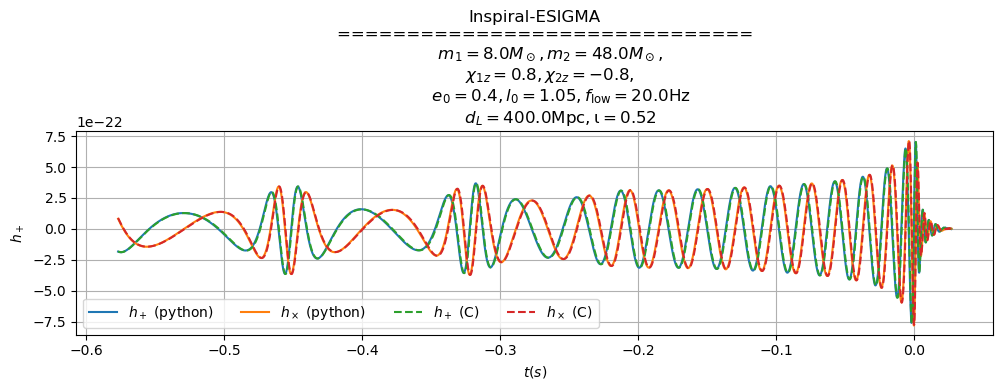

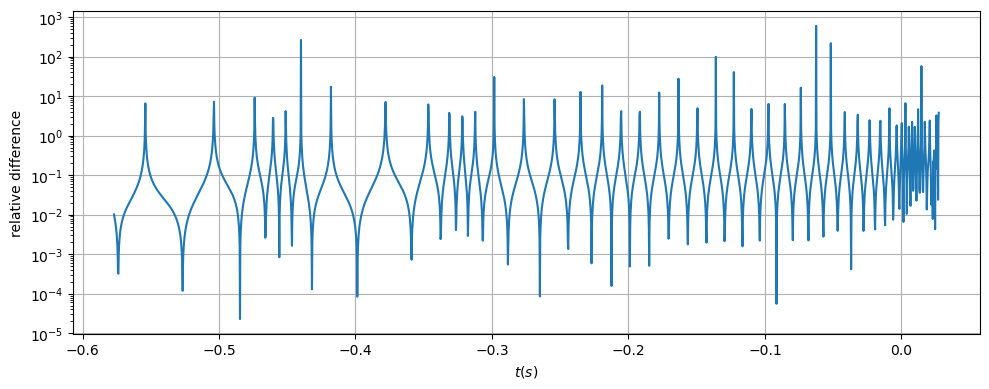

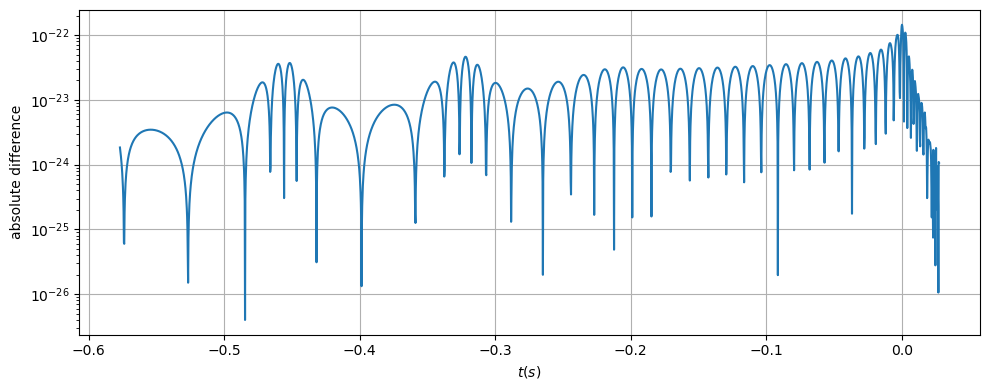

In [58]:
print(len(hp_py))
print(len(hp_c))

plt.figure(figsize=(10, 4))
plt.title(
    rf"""Inspiral-ESIGMA
    ==============================
      $m_1={m1} M_\odot, m_2={m2} M_\odot$, 
      $\chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$, 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)

hp_py.plot(label=r"$h_+$ (python)")
hc_py.plot(label=r"$h_\times$ (python)")

hp_c.plot(label=r"$h_+$ (C)",ls='--')
hc_c.plot(label=r"$h_\times$ (C)",ls='--')

plt.xlabel(r"$t (s)$")
plt.ylabel("$h_+$")
plt.legend(ncol=4,loc='lower left')
plt.grid()
# plt.xlim(0.7,0.74)
# plt.ylim(-1e-21,1e-21)
plt.tight_layout()
plt.show()

### Plotting difference ##

eps = 1e-30
abs_diff = np.abs(hp_py-hp_c)
rel_diff = abs_diff / np.maximum(np.abs(hp_c), eps)

plt.figure(figsize=(10, 4))
plt.semilogy(hp_py.sample_times,rel_diff)
plt.xlabel(r"$t (s)$")
plt.ylabel('relative difference')
plt.grid()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))
plt.semilogy(hp_py.sample_times,abs_diff)
plt.xlabel(r"$t (s)$")
plt.ylabel('absolute difference')
plt.grid()
plt.tight_layout()
plt.show()

### Match between waveforms

In [ ]:
from pycbc.filter import match
from pycbc.psd import aLIGOZeroDetHighPower

f_low = 20.5

tlen = max(len(hp_c), len(hp_py))
hp_c.resize(tlen)
hp_py.resize(tlen)

# Generate the aLIGO ZDHP PSD
delta_f = 1.0 / hp_c.duration
flen = tlen//2 + 1
psd = aLIGOZeroDetHighPower(flen, delta_f, f_low)

# Note: This takes a while the first time as an FFT plan is generated
# subsequent calls are much faster.
match1, _ = match(hp_c, hp_py, psd=psd, low_frequency_cutoff=f_low)
mm = (1-match1)*100
print(f'The mismatch is: {mm:.4f}%')

The mismatch is: 0.0501%


## ============== Extracting orbital variables ============

In [63]:
# orb_params_list = ["x", "e", "l", "r", "rdot", "phi", "phidot"]

out_c = lalsim.SimInspiralESIGMADynamics(m1,m2,spin1z,spin2z,eccentricity,f_low,mean_anomaly,1e-12,1/delta_t)

time_c = out_c[0].data.data
x_c = out_c[1].data.data
e_c = out_c[2].data.data
meanan_c = out_c[3].data.data
phi_c = out_c[4].data.data
phidot_c = out_c[5].data.data
r_c = out_c[6].data.data
rdot_c = out_c[7].data.data

out_py = espn.inspiral_esigma_dynamics(m1,m2,spin1z,spin2z,eccentricity,f_low,mean_anomaly,1e-12,1/delta_t,)
print(out_py.keys())
time_py = out_py['time_evol']/(m1+m2)/lal.MTSUN_SI
x_py = out_py['x_evol']
e_py = out_py['eccentricity_evol']
meanan_py = out_py['mean_ano_evol']
phi_py = out_py['phi_evol']
phidot_py = out_py['phi_dot_evol']
r_py = out_py['r_evol']
rdot_py = out_py['r_dot_evol']

dict_keys(['time_evol', 'x_evol', 'eccentricity_evol', 'mean_ano_evol', 'phi_evol', 'phi_dot_evol', 'r_evol', 'r_dot_evol'])


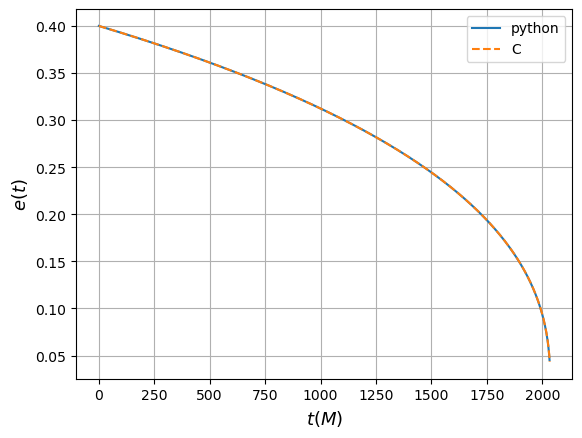

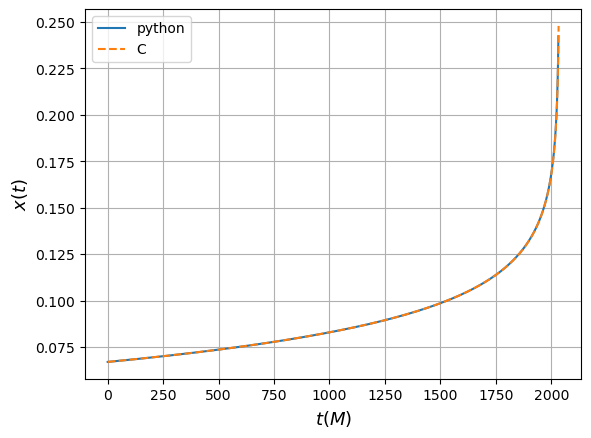

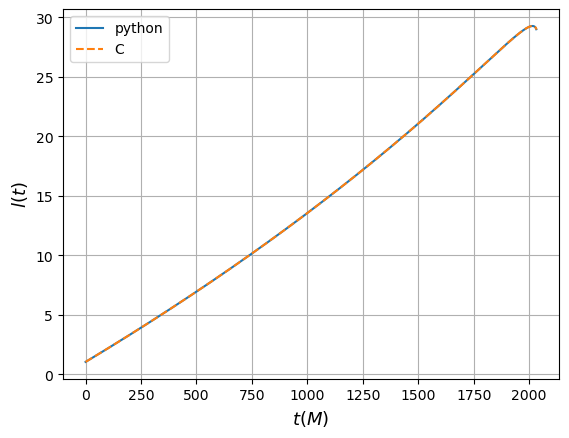

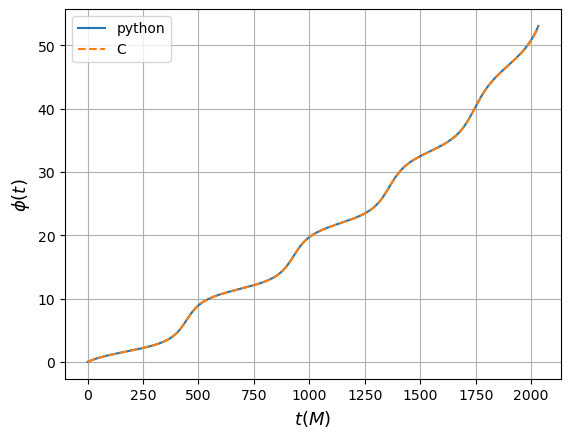

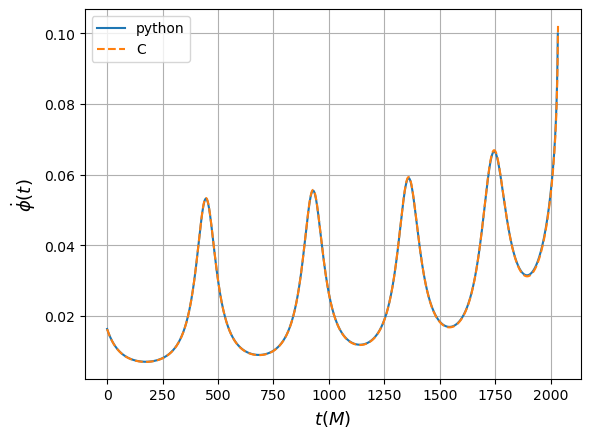

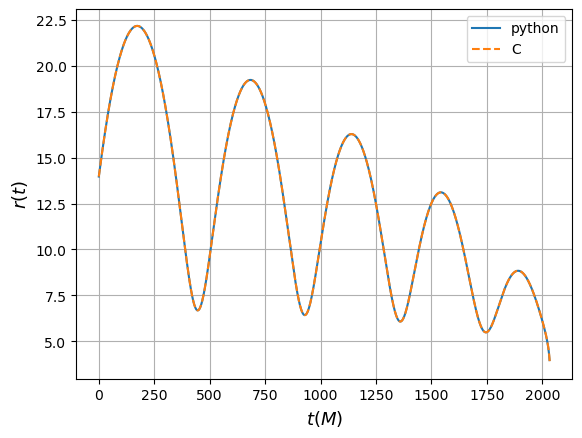

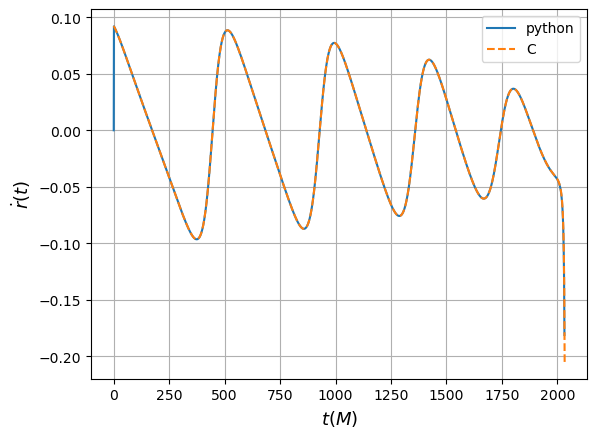

In [64]:
plt.plot(time_py,e_py,label='python')
plt.plot(time_c,e_c,ls='--',label='C')
plt.xlabel('$t (M)$',fontsize=13)
plt.ylabel('$e (t)$',fontsize=13)
plt.legend(), plt.grid()
plt.show()

plt.plot(time_py,x_py,label='python')
plt.plot(time_c,x_c,ls='--',label='C')
plt.xlabel('$t (M)$',fontsize=13)
plt.ylabel('$x (t)$',fontsize=13)
plt.legend(), plt.grid()
plt.show()

plt.plot(time_py,meanan_py,label='python')
plt.plot(time_c,meanan_c,ls='--',label='C')
plt.xlabel('$t (M)$',fontsize=13)
plt.ylabel('$l (t)$',fontsize=13)
plt.legend(), plt.grid()
plt.show()

plt.plot(time_py,phi_py,label='python')
plt.plot(time_c,phi_c,ls='--',label='C')
plt.xlabel('$t (M)$',fontsize=13)
plt.ylabel('$\\phi (t)$',fontsize=13)
plt.legend(), plt.grid()
plt.show()

plt.plot(time_py,phidot_py,label='python')
plt.plot(time_c,phidot_c,ls='--',label='C')
plt.xlabel('$t (M)$',fontsize=13)
plt.ylabel('$\\dot{\\phi} (t)$',fontsize=13)
plt.legend(), plt.grid()
plt.show()

plt.plot(time_py,r_py,label='python')
plt.plot(time_c,r_c,ls='--',label='C')
plt.xlabel('$t (M)$',fontsize=13)
plt.ylabel('$r (t)$',fontsize=13)
plt.legend(), plt.grid()
plt.show()

plt.plot(time_py,rdot_py,label='python')
plt.plot(time_c,rdot_c,ls='--',label='C')
plt.xlabel('$t (M)$',fontsize=13)
plt.ylabel('$\\dot{r} (t)$',fontsize=13)
plt.legend(), plt.grid()
plt.show()